# **Preetha's version - test run**

In [ ]:
!pip install -q wbgapi faostat pycountry pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 29.5 MB/s eta 0:00:00


In [ ]:
import os, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests

CACHE = Path("data_cache")
CACHE.mkdir(exist_ok=True)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore")

def get_json(url, params=None, tries=3, pause=2):
    """GET with light retry. Returns parsed JSON or None."""
    for attempt in range(tries):
        try:
            r = requests.get(url, params=params, timeout=60)
            r.raise_for_status()
            return r.json()
        except Exception as exc:
            print(f"  attempt {attempt+1}/{tries} failed: {exc}")
            time.sleep(pause)
    return None

def save(df, name):
    path = CACHE / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"saved {name}: {df.shape[0]} rows x {df.shape[1]} cols -> {path}")
    return path

In [ ]:
raw = get_json("https://api.worldbank.org/v2/country",
               params={"format": "json", "per_page": 400})

records = []
for c in raw[1]:
    records.append({
        "iso3": c["id"],
        "iso2": c["iso2Code"],
        "country": c["name"],
        "region": c["region"]["value"],
        "region_id": c["region"]["id"],
        "income_group": c["incomeLevel"]["value"],
        "lat": c.get("latitude"),
        "lon": c.get("longitude"),
    })

countries = pd.DataFrame(records)

# Aggregates are flagged by region == "Aggregates"
aggregates = countries[countries["region"] == "Aggregates"]
countries = countries[countries["region"] != "Aggregates"].reset_index(drop=True)

print(f"{len(countries)} economies, {len(aggregates)} aggregates dropped")
print(countries["region"].value_counts())
save(countries, "countries")
countries.head()

217 economies, 78 aggregates dropped
region
Europe & Central Asia                                58
Sub-Saharan Africa                                   48
Latin America & Caribbean                            42
East Asia & Pacific                                  37
Middle East, North Africa, Afghanistan & Pakistan    23
South Asia                                            6
North America                                         3
Name: count, dtype: int64
saved countries: 217 rows x 8 cols -> data_cache/countries.csv


,iso3,iso2,country,region,region_id,income_group,lat,lon
0,ABW,AW,Aruba,Latin America & Caribbean,LCN,High income,12.5167,-70.0167
1,AFG,AF,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",MEA,Low income,34.5228,69.1761
2,AGO,AO,Angola,Sub-Saharan Africa,SSF,Lower middle income,-8.81155,13.242
3,ALB,AL,Albania,Europe & Central Asia,ECS,Upper middle income,41.3317,19.8172
4,AND,AD,Andorra,Europe & Central Asia,ECS,High income,42.5075,1.5218


In [ ]:
sources = get_json("https://api.worldbank.org/v2/sources",
                   params={"format": "json", "per_page": 200})[1]

hits = [s for s in sources
        if any(k in s["name"].lower() for k in ["food price", "nutrition", "fpn"])]

print("Candidate sources:\n")
for s in hits:
    print(f"  id={s['id']:>4}  {s['name']}")
    print(f"        last updated: {s.get('lastupdated')}")

if not hits:
    print("No match. Full source list:")
    for s in sources:
        print(f"  id={s['id']:>4}  {s['name']}")

Candidate sources:

  id=   5  Subnational Malnutrition Database
        last updated: 2016-03-21
  id=  16  Health Nutrition and Population Statistics
        last updated: 2026-07-01
  id=  39  Health Nutrition and Population Statistics by Wealth Quintile
        last updated: 2022-12-13
  id=  88  Food Prices for Nutrition
        last updated: 2026-07-21
  id=  93  FPN Datahub Archive
        last updated: 2026-07-21


In [ ]:
IND = "CoHD_PPP"

CANDIDATES = {
    "A": (f"https://api.worldbank.org/v2/country/all/indicator/{IND}",
          {"source": 88, "format": "json", "per_page": 5}),
    "B": (f"https://api.worldbank.org/v2/sources/88/country/all/series/{IND}/data",
          {"format": "json", "per_page": 5}),
    "C": (f"https://api.worldbank.org/v2/sources/88/series/{IND}/country/all/time/all/data",
          {"format": "json", "per_page": 5}),
    "D": (f"https://api.worldbank.org/v2/indicator/{IND}",
          {"source": 88, "format": "json"}),
}

for label, (url, params) in CANDIDATES.items():
    print("=" * 60)
    print(label)
    try:
        r = requests.get(url, params=params, timeout=30)
        print(f"  HTTP {r.status_code}")
        print("  " + r.text[:500].replace("\n", "\n  "))
    except Exception as e:
        print("  failed:", e)

A
  HTTP 200
  [{"message":[{"id":"175","key":"Invalid format","value":"The indicator was not found. It may have been deleted or archived."}]}]
B
  HTTP 200
  {"page":1,"pages":346,"per_page":5,"total":1728,"lastupdated":"2026-07-21","source":{"id":"88","name":"Food Prices for Nutrition","data":[{"variable":[{"concept":"Country","id":"ALB","value":"Albania"},{"concept":"Time","id":"YR2017","value":"2017"},{"concept":"Series","id":"CoHD_PPP","value":"Cost of a healthy diet in PPP dollars"},{"concept":"Classification","id":"FPN 5.0","value":"Food Prices for Nutrition 5.0"}],"value":3.04},{"variable":[{"concept":"Country","id":"ALB","value":"Albania"},{"
C
  HTTP 200
  {"page":1,"pages":346,"per_page":5,"total":1728,"lastupdated":"2026-07-21","source":{"id":"88","name":"Food Prices for Nutrition","data":[{"variable":[{"concept":"Series","id":"CoHD_PPP","value":"Cost of a healthy diet in PPP dollars"},{"concept":"Classification","id":"FPN 5.0","value":"Food Prices for Nutrition 5.0"},{"con

In [ ]:
# Set this from the printed output above. Do not guess it.
FPN_SOURCE_ID = 88   # <-- fill in

assert FPN_SOURCE_ID is not None, "Set FPN_SOURCE_ID from the cell above first."

series = get_json("https://api.worldbank.org/v2/indicator",
                  params={"source": FPN_SOURCE_ID, "format": "json", "per_page": 500})[1]

fpn_series = pd.DataFrame([{"code": s["id"], "name": s["name"]} for s in series])
print(f"{len(fpn_series)} indicators in source {FPN_SOURCE_ID}\n")

# The ones we care about: overall diet cost, the six food group costs, affordability
for pat in ["cost", "afford", "food group", "healthy"]:
    sub = fpn_series[fpn_series["name"].str.contains(pat, case=False, na=False)]
    print(f"--- matching '{pat}' ({len(sub)}) ---")
    for _, r in sub.iterrows():
        print(f"  {r['code']:<32} {r['name'][:100]}")
    print()

45 indicators in source 88

--- matching 'cost' (36) ---
  CoCA_fexp                        Affordability of an energy sufficient diet: ratio of cost to food expenditures
  CoCA_LCU                         Cost of an energy sufficient diet in local currency unit
  CoCA_pov                         Affordability of an energy sufficient diet: ratio of cost to the food poverty line
  CoCA_PPP                         Cost of an energy sufficient diet in PPP dollars
  CoHD_asf_LCU                     Cost of animal source foods in local currency unit
  CoHD_asf_PPP                     Cost of animal source foods in PPP dollars
  CoHD_asf_prop                    Cost share for animal-sourced foods in a least-cost healthy diet
  CoHD_asf_ss                      Cost of animal-sourced foods relative to the starchy staples in a least-cost healthy diet
  CoHD_CoCA                        Cost of a healthy diet relative to the cost of sufficient energy from starchy staples
  CoHD_f_LCU             

In [ ]:
!pip install wbgapi

In [ ]:
GROUPS = ["ss", "v", "f", "asf", "lns", "of"]

FPN_INDICATORS = (
    ["CoHD_PPP", "CoHD_LCU", "CoHD_headcount",
     "CoHD_unafford_n", "CoHD_fexp", "CoHD_pov"]
    + [f"CoHD_{g}_PPP"  for g in GROUPS]
    + [f"CoHD_{g}_LCU"  for g in GROUPS]
    + [f"CoHD_{g}_prop" for g in GROUPS]
)

def fpn_series(indicator, source=88, per_page=20000):
    """Source-scoped DataBank pull. Response nests values under source.data."""
    url = f"https://api.worldbank.org/v2/sources/{source}/country/all/series/{indicator}/data"
    rows, page = [], 1
    while True:
        payload = get_json(url, params={"format": "json",
                                        "per_page": per_page, "page": page})
        if not payload or "source" not in payload:
            print(f"    unexpected response for {indicator}: {str(payload)[:200]}")
            break
        for rec in payload["source"]["data"]:
            v = {d["concept"]: d["id"] for d in rec["variable"]}
            rows.append({
                "iso3": v.get("Country"),
                "year": int(v.get("Time", "YR0").replace("YR", "")),
                "indicator": v.get("Series"),
                "version": v.get("Classification"),
                "value": rec["value"],
            })
        if page >= payload.get("pages", 1):
            break
        page += 1
    return rows

all_rows = []
for i, ind in enumerate(FPN_INDICATORS, 1):
    got = fpn_series(ind)
    n_val = sum(r["value"] is not None for r in got)
    all_rows.extend(got)
    print(f"  [{i:>2}/{len(FPN_INDICATORS)}] {ind:<18} {len(got):>6} rows, {n_val:>5} non-null")

fpn = pd.DataFrame(all_rows)
print("\nversion served:", fpn["version"].unique())

fpn = fpn.dropna(subset=["value"])
fpn = fpn[fpn["iso3"].isin(countries["iso3"])]

print(fpn.shape)
print("\nnon-null country-years per indicator:")
print(fpn.groupby("indicator").size().sort_values().to_string())

save(fpn, "fpn")
fpn.head(10)

  [ 1/24] CoHD_PPP             1728 rows,  1629 non-null
  [ 2/24] CoHD_LCU             1728 rows,  1586 non-null
  [ 3/24] CoHD_headcount       1728 rows,  1431 non-null
  [ 4/24] CoHD_unafford_n      1728 rows,  1431 non-null
  [ 5/24] CoHD_fexp            1728 rows,   182 non-null
  [ 6/24] CoHD_pov             1728 rows,  1612 non-null
  [ 7/24] CoHD_ss_PPP          1728 rows,   177 non-null
  [ 8/24] CoHD_v_PPP           1728 rows,   177 non-null
  [ 9/24] CoHD_f_PPP           1728 rows,   177 non-null
  [10/24] CoHD_asf_PPP         1728 rows,   177 non-null
  [11/24] CoHD_lns_PPP         1728 rows,   177 non-null
  [12/24] CoHD_of_PPP          1728 rows,   177 non-null
  [13/24] CoHD_ss_LCU          1728 rows,   171 non-null
  [14/24] CoHD_v_LCU           1728 rows,   171 non-null
  [15/24] CoHD_f_LCU           1728 rows,   171 non-null
  [16/24] CoHD_asf_LCU         1728 rows,   171 non-null
  [17/24] CoHD_lns_LCU         1728 rows,   171 non-null
  [18/24] CoHD_of_LCU          

,iso3,year,indicator,version,value
0,ALB,2017,CoHD_PPP,FPN 5.0,3.04
1,ALB,2018,CoHD_PPP,FPN 5.0,3.13
2,ALB,2019,CoHD_PPP,FPN 5.0,3.32
3,ALB,2020,CoHD_PPP,FPN 5.0,3.40
4,ALB,2021,CoHD_PPP,FPN 5.0,3.49
5,ALB,2022,CoHD_PPP,FPN 5.0,4.17
6,ALB,2023,CoHD_PPP,FPN 5.0,4.88
7,ALB,2024,CoHD_PPP,FPN 5.0,4.99
8,ALB,2025,CoHD_PPP,FPN 5.0,5.16
9,DZA,2017,CoHD_PPP,FPN 5.0,4.09


In [ ]:
print(fpn[fpn["indicator"] == "CoHD_ss_PPP"]["year"].value_counts().sort_index())

year
2021    161
Name: count, dtype: int64


In [ ]:
# PPP base year check. This is the cell that stops a silent unit mismatch.
# FPN documents its PPP base in the DataHub methodology; PIP reports it per query.
print("FPN source metadata:")
meta = get_json(f"https://api.worldbank.org/v2/sources/{FPN_SOURCE_ID}",
                params={"format": "json"})
print(json.dumps(meta[1][0], indent=2)[:1500])

FPN source metadata:
{
  "id": "88",
  "lastupdated": "2026-07-21",
  "name": "Food Prices for Nutrition",
  "code": "FPN",
  "description": "",
  "url": "",
  "dataavailability": "Y",
  "metadataavailability": "Y",
  "concepts": "4"
}


In [ ]:
PIP_CANDIDATES = [
    "https://api.worldbank.org/pip/v1",
    "https://pip.worldbank.org/api/v1",
]

PIP_BASE = None
for base in PIP_CANDIDATES:
    print(f"trying {base} ...")
    probe = get_json(f"{base}/versions", tries=1)
    if probe is not None:
        PIP_BASE = base
        print(f"  ok\n")
        break

if PIP_BASE is None:
    print("Neither responded. Check https://pip.worldbank.org/api for the current base URL.")
else:
    versions = pd.DataFrame(probe)
    print(versions.head(10).to_string())
    print("\nPPP versions available:", sorted(versions.get('ppp_version', pd.Series()).unique()))

trying https://api.worldbank.org/pip/v1 ...
  ok

                    version release_version ppp_version identity
0  20260324_2021_01_02_PROD        20260324        2021     PROD
1  20260324_2017_01_02_PROD        20260324        2017     PROD
2  20250930_2021_01_02_PROD        20250930        2021     PROD
3  20250930_2017_01_02_PROD        20250930        2017     PROD
4  20250401_2021_01_02_PROD        20250401        2021     PROD
5  20250401_2017_01_02_PROD        20250401        2017     PROD
6  20240627_2017_01_02_PROD        20240627        2017     PROD
7  20240627_2011_02_02_PROD        20240627        2011     PROD
8  20240326_2017_01_02_PROD        20240326        2017     PROD
9  20240326_2011_02_02_PROD        20240326        2011     PROD

PPP versions available: ['2011', '2017', '2021']


In [ ]:
# Baseline pull at a standard line, to establish coverage and vintage.
# Stage 1 will re-query at country-specific lines equal to the diet cost.
resp = get_json(f"{PIP_BASE}/pip", params={
    "country": "all",
    "year": "all",
    "povline": 3.00,
    "fill_gaps": "false",
    "welfare_type": "all",
    "format": "json",
})

pip_df = pd.DataFrame(resp)
keep = [c for c in ["country_code", "country_name", "reporting_year", "survey_year",
                    "welfare_type", "reporting_level", "headcount", "mean",
                    "gini", "ppp_version", "poverty_line"] if c in pip_df.columns]
pip_df = pip_df[keep].rename(columns={"country_code": "iso3"})

print(pip_df.shape)
print("\nColumns returned:", list(pip_df.columns))
save(pip_df, "pip_baseline")
pip_df.head()

(2584, 10)

Columns returned: ['iso3', 'country_name', 'reporting_year', 'survey_year', 'welfare_type', 'reporting_level', 'headcount', 'mean', 'gini', 'poverty_line']
saved pip_baseline: 2584 rows x 10 cols -> data_cache/pip_baseline.csv


,iso3,country_name,reporting_year,survey_year,welfare_type,reporting_level,headcount,mean,gini,poverty_line
0,AGO,Angola,2000,2000.21,consumption,national,0.2695,8.3803,0.5195,3
1,AGO,Angola,2008,2008.50,consumption,national,0.2208,7.4017,0.4272,3
2,AGO,Angola,2018,2018.17,consumption,national,0.3929,6.2181,0.5126,3
3,ALB,Albania,1996,1996.00,consumption,national,0.0297,8.4420,0.2701,3
4,ALB,Albania,2002,2002.00,consumption,national,0.0419,8.6283,0.3174,3


In [ ]:
# Survey vintage: the input to the data density overlay.
latest = (pip_df.sort_values("reporting_year")
                .groupby("iso3", as_index=False)
                .last()[["iso3", "reporting_year", "survey_year", "welfare_type"]])

latest["years_stale"] = 2026 - pd.to_numeric(latest["reporting_year"], errors="coerce")

print(latest["years_stale"].describe())
print("\nCountries with survey older than 7 years:")
print(latest[latest["years_stale"] > 7].sort_values("years_stale", ascending=False).head(25).to_string(index=False))

save(latest, "pip_vintage")

count    172.000000
mean       6.156977
std        5.020870
min        1.000000
25%        3.000000
50%        5.000000
75%        8.000000
max       34.000000
Name: years_stale, dtype: float64

Countries with survey older than 7 years:
iso3  reporting_year  survey_year welfare_type  years_stale
 TTO            1992      1992.00       income           34
 GUY            1998      1998.00       income           28
 TKM            1998      1998.00  consumption           28
 AZE            2005      2005.00  consumption           21
 VEN            2006      2006.00       income           20
 PNG            2009      2009.67  consumption           17
 TUV            2010      2010.00  consumption           16
 JOR            2010      2010.24  consumption           16
 DZA            2011      2011.17  consumption           15
 COG            2011      2011.67  consumption           15
 HTI            2012      2012.00       income           14
 SLB            2012      2012.79  consumpt

PosixPath('data_cache/pip_vintage.csv')

In [ ]:
WDI = {
    "NY.GDP.PCAP.PP.KD": "gdp_pc_ppp",
    "SP.URB.TOTL.IN.ZS": "urban_share",
    "SP.RUR.TOTL.ZS":    "rural_share",
    "SI.POV.GINI":       "gini_wdi",
    "AG.LND.AGRI.ZS":    "agri_land_share",
    "SL.AGR.EMPL.ZS":    "agri_employment_share",
    "NV.AGR.TOTL.ZS":    "agri_value_added_share",
    "PA.NUS.FCRF":       "exchange_rate_lcu_usd",
}

def wdi_series(indicator, start=2010, end=2025, per_page=20000):
    """WDI uses the standard /country/all/indicator path (shape A)."""
    url = f"https://api.worldbank.org/v2/country/all/indicator/{indicator}"
    rows, page = [], 1
    while True:
        payload = get_json(url, params={"format": "json", "date": f"{start}:{end}",
                                        "per_page": per_page, "page": page})
        if not payload or len(payload) < 2 or not isinstance(payload[1], list):
            print(f"    unexpected response for {indicator}: {str(payload)[:200]}")
            break
        for r in payload[1]:
            rows.append({
                "iso3": r["countryiso3code"],
                "year": int(r["date"]),
                "indicator": indicator,
                "value": r["value"],
            })
        if page >= payload[0].get("pages", 1):
            break
        page += 1
    return rows

all_rows = []
for i, (code, name) in enumerate(WDI.items(), 1):
    got = wdi_series(code)
    n_val = sum(r["value"] is not None for r in got)
    all_rows.extend(got)
    print(f"  [{i}/{len(WDI)}] {name:<24} {len(got):>6} rows, {n_val:>5} non-null")

wdi = pd.DataFrame(all_rows).dropna(subset=["value"])
wdi["indicator"] = wdi["indicator"].map(WDI)
wdi = wdi[wdi["iso3"].isin(countries["iso3"])]

print(wdi.shape)
print("\ncountries with data, by feature:")
print(wdi.groupby("indicator")["iso3"].nunique().sort_values().to_string())

save(wdi, "wdi")
wdi.head()

  [1/8] gdp_pc_ppp                 4240 rows,  3913 non-null
  [2/8] urban_share                4240 rows,  4224 non-null
  [3/8] rural_share                4240 rows,  4224 non-null
  [4/8] gini_wdi                   4240 rows,  1145 non-null
  [5/8] agri_land_share            4240 rows,  3592 non-null
  [6/8] agri_employment_share      4240 rows,  3730 non-null
  [7/8] agri_value_added_share     4240 rows,  3861 non-null
  [8/8] exchange_rate_lcu_usd      4240 rows,  3317 non-null
(23584, 4)

countries with data, by feature:
indicator
gini_wdi                  165
agri_employment_share     187
gdp_pc_ppp                199
agri_value_added_share    204
agri_land_share           210
exchange_rate_lcu_usd     212
rural_share               217
urban_share               217
saved wdi: 23584 rows x 4 cols -> data_cache/wdi.csv


,iso3,year,indicator,value
769,AFG,2024,gdp_pc_ppp,1964.452289
770,AFG,2023,gdp_pc_ppp,1983.812620
771,AFG,2022,gdp_pc_ppp,1981.710168
772,AFG,2021,gdp_pc_ppp,2144.166570
773,AFG,2020,gdp_pc_ppp,2769.685745


In [ ]:
fg = set(fpn[fpn["indicator"] == "CoHD_ss_PPP"]["iso3"])
print(f"food-group countries: {len(fg)}")

w2021 = wdi[wdi["year"] == 2021]
for name in WDI.values():
    have = set(w2021[w2021["indicator"] == name]["iso3"]) & fg
    print(f"  {name:<24} {len(have):>3} of {len(fg)}")

food-group countries: 161
  gdp_pc_ppp               159 of 161
  urban_share              161 of 161
  rural_share              161 of 161
  gini_wdi                  73 of 161
  agri_land_share          160 of 161
  agri_employment_share    151 of 161
  agri_value_added_share   159 of 161
  exchange_rate_lcu_usd    158 of 161


In [ ]:
fx = (wdi[wdi["indicator"] == "exchange_rate_lcu_usd"]
        .pivot(index="year", columns="iso3", values="value")
        .sort_index())
fx_vol = fx.pct_change().std().rename("fx_volatility")
print(fx_vol.describe())

count    212.000000
mean       0.270928
std        2.095647
min        0.000000
25%        0.036347
50%        0.071339
75%        0.084308
max       30.110879
Name: fx_volatility, dtype: float64


FAOSTAT import dependence

In [ ]:
r = requests.get("https://fenixservices.fao.org/faostat/api/v1/en/definitions/domain",
                 timeout=30)
print(r.status_code, r.text[:300])

521 <!DOCTYPE html>
<!--[if lt IE 7]> <html class="no-js ie6 oldie" lang="en-US"> <![endif]-->
<!--[if IE 7]>    <html class="no-js ie7 oldie" lang="en-US"> <![endif]-->
<!--[if IE 8]>    <html class="no-js ie8 oldie" lang="en-US"> <![endif]-->
<!--[if gt IE 8]><!--> <html class="no-js" lang="en-US"> <!


In [ ]:
extra = {
    "TM.VAL.FOOD.ZS.UN": "food_imports_pct_merch",
    "AG.PRD.FOOD.XD":    "food_production_index",
}

rows = []
for code, name in extra.items():
    got = wdi_series(code)
    n_val = sum(r["value"] is not None for r in got)
    rows.extend(got)
    print(f"  {name:<26} {len(got):>6} rows, {n_val:>5} non-null")

extra_df = pd.DataFrame(rows).dropna(subset=["value"])
extra_df["indicator"] = extra_df["indicator"].map(extra)
extra_df = extra_df[extra_df["iso3"].isin(countries["iso3"])]

e2021 = extra_df[extra_df["year"] == 2021]
for name in extra.values():
    print(f"  {name:<26} {len(set(e2021[e2021['indicator']==name]['iso3']) & fg):>3} of 161")

wdi = pd.concat([wdi, extra_df], ignore_index=True)
save(wdi, "wdi")

  food_imports_pct_merch       4240 rows,  3189 non-null
  food_production_index        4240 rows,  3048 non-null
  food_imports_pct_merch     145 of 161
  food_production_index      156 of 161
saved wdi: 28640 rows x 4 cols -> data_cache/wdi.csv


PosixPath('data_cache/wdi.csv')

In [ ]:
!curl -sI "https://bulks-faostat.fao.org/production/FoodBalanceSheets_E_All_Data_(Normalized).zip" | head -5

HTTP/2 200 
content-type: application/x-zip-compressed
content-length: 54840802
date: Thu, 03 Sep 2026 20:09:08 GMT
last-modified: Tue, 28 Oct 2025 08:46:05 GMT


In [ ]:
!wget -q -O fbs.zip "https://bulks-faostat.fao.org/production/FoodBalanceSheets_E_All_Data_(Normalized).zip"
!ls -lh fbs.zip

import zipfile
with zipfile.ZipFile("fbs.zip") as z:
    print(z.namelist())

-rw-r--r-- 1 root root 53M Oct 28  2025 fbs.zip
['FoodBalanceSheets_E_All_Data_(Normalized).csv', 'FoodBalanceSheets_E_AreaCodes.csv', 'FoodBalanceSheets_E_Elements.csv', 'FoodBalanceSheets_E_Flags.csv', 'FoodBalanceSheets_E_ItemCodes.csv']


In [ ]:
CSV = "FoodBalanceSheets_E_All_Data_(Normalized).csv"   # correct from the printout

cols = None
chunks = []
with zipfile.ZipFile("fbs.zip") as z:
    for chunk in pd.read_csv(z.open(CSV), encoding="latin-1", chunksize=500_000):
        if cols is None:
            cols = list(chunk.columns)
            print(cols)
        chunks.append(chunk[chunk["Year"] == 2021])

fbs = pd.concat(chunks, ignore_index=True)
print(fbs.shape)
print(fbs["Element"].unique()[:20])
print(fbs["Item"].unique()[:20])

['Area Code', 'Area Code (M49)', 'Area', 'Item Code', 'Item Code (FBS)', 'Item', 'Element Code', 'Element', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Note']
(350578, 14)
['Total Population - Both sexes' 'Food supply (kcal/capita/day)'
 'Food supply (kcal)' 'Protein supply quantity (g/capita/day)'
 'Protein supply quantity (t)' 'Fat supply quantity (g/capita/day)'
 'Fat supply quantity (t)' 'Import quantity' 'Production'
 'Stock Variation' 'Export quantity' 'Domestic supply quantity' 'Feed'
 'Losses' 'Other uses (non-food)' 'Seed' 'Residuals' 'Food' 'Processing'
 'Food supply quantity (kg/capita/yr)']
['Population' 'Grand Total' 'Vegetal Products' 'Animal Products'
 'Cereals - Excluding Beer' 'Wheat and products' 'Rice and products'
 'Barley and products' 'Maize and products' 'Rye and products' 'Oats'
 'Sorghum and products' 'Cereals, other' 'Millet and products'
 'Starchy Roots' 'Cassava and products' 'Potatoes and products'
 'Sweet potatoes' 'Roots, Other' 'Sugar Crops']


In [ ]:
import pycountry

def m49_to_iso3(code):
    try:
        c = pycountry.countries.get(numeric=str(int(code)).zfill(3))
        return c.alpha_3 if c else None
    except Exception:
        return None

#MANUAL = {
    # Known M49 / ISO3 gaps. Extend as the printout below reveals them.
    # 158: "TWN",   # Taiwan, reported by FAOSTAT, absent from WB
    # 830: None,    # Channel Islands
#}
MANUAL = {
    "'159": "CHN",
}

if "area_code_m49" in fbs.columns:
    src_col = "area_code_m49"
elif "Area Code (M49)" in fbs.columns:
    src_col = "Area Code (M49)"
else:
    src_col = [c for c in fbs.columns if "area" in c.lower() and "code" in c.lower()][0]

fbs["m49_clean"] = fbs[src_col].astype(str).str.replace("'", "", regex=False)
fbs["iso3"] = fbs["m49_clean"].map(lambda x: MANUAL.get(x, m49_to_iso3(x)))

unmatched = fbs[fbs["iso3"].isna()][[src_col, "Area"]].drop_duplicates() \
    if "Area" in fbs.columns else fbs[fbs["iso3"].isna()][[src_col]].drop_duplicates()

print(f"{len(unmatched)} FAOSTAT areas did not map to ISO3:")
print(unmatched.to_string(index=False))

35 FAOSTAT areas did not map to ISO3:
Area Code (M49)                                             Area
           '159                                            China
           '001                                            World
           '002                                           Africa
           '014                                   Eastern Africa
           '017                                    Middle Africa
           '015                                  Northern Africa
           '018                                  Southern Africa
           '011                                   Western Africa
           '019                                         Americas
           '021                                 Northern America
           '013                                  Central America
           '029                                        Caribbean
           '005                                    South America
           '142                                     

In [ ]:
ELEMENTS = ["Production", "Import quantity", "Export quantity", "Domestic supply quantity"]

dep = (fbs[fbs["Element"].isin(ELEMENTS) & (fbs["Item"] == "Cereals - Excluding Beer")]
       .pivot_table(index="iso3", columns="Element", values="Value"))

dep["import_dependence"] = dep["Import quantity"] / dep["Domestic supply quantity"]
dep = dep.replace([np.inf, -np.inf], np.nan)

print(dep["import_dependence"].describe())
print(f"\nin the 161 food-group sample: {len(set(dep.index) & fg)}")

save(dep.reset_index(), "import_dependence")

count    176.000000
mean       0.617088
std        0.402115
min        0.001751
25%        0.266857
50%        0.574372
75%        0.992006
max        1.749881
Name: import_dependence, dtype: float64

in the 161 food-group sample: 143
saved import_dependence: 176 rows x 6 cols -> data_cache/import_dependence.csv


PosixPath('data_cache/import_dependence.csv')

In [ ]:
spine = countries[["iso3", "country", "region", "income_group"]].copy()

def has(df, name):
    if df is None or "iso3" not in df.columns:
        return pd.Series(dtype=bool)
    return pd.Series(True, index=pd.Index(df["iso3"].dropna().unique(), name="iso3"), name=name)

flags = spine.set_index("iso3")
for name, df in [("fpn", fpn), ("pip", pip_df), ("wdi", wdi), ("fbs", fbs)]:
    flags[name] = flags.index.isin(df["iso3"].dropna().unique()) if df is not None else False

flags = flags.merge(latest.set_index("iso3")[["years_stale"]],
                    left_index=True, right_index=True, how="left")

#flags["complete"] = flags[["fpn", "pip", "wdi", "fbs"]].all(axis=1)
#flags["usable"] = flags["complete"] & (flags["years_stale"] <= 7)

flags["complete"] = flags[["fpn", "pip", "wdi", "fbs"]].all(axis=1)
flags["core"] = flags[["fpn", "pip", "wdi"]].all(axis=1)
flags["usable"] = flags["core"] & (flags["years_stale"] <= 10)

print(f"economies in spine:            {len(flags)}")
#print(f"present in all four sources:   {flags['complete'].sum()}")
#print(f"of those, survey <= 7 yrs old: {flags['usable'].sum()}")
print(f"core (fpn+pip+wdi):            {flags['core'].sum()}")
print(f"  of those, survey <= 10 yrs:  {flags['usable'].sum()}")
print(f"also with fbs (robustness):    {flags['complete'].sum()}")
print()
print("Coverage by source:")
print(flags[["fpn", "pip", "wdi", "fbs"]].sum().to_string())
print()
print("Complete-case count by region:")
print(flags[flags["complete"]].groupby("region").size().to_string())
print()
print("Dropped, with reason:")
missing = flags[~flags["complete"]].copy()
missing["missing_from"] = missing[["fpn", "pip", "wdi", "fbs"]].apply(
    lambda r: ",".join([c for c in ["fpn", "pip", "wdi", "fbs"] if not r[c]]), axis=1)
print(missing[["country", "region", "missing_from"]].to_string())

save(flags.reset_index(), "coverage_report")

economies in spine:            217
core (fpn+pip+wdi):            152
  of those, survey <= 10 yrs:  138
also with fbs (robustness):    141

Coverage by source:
fpn    174
pip    171
wdi    217
fbs    175

Complete-case count by region:
region
East Asia & Pacific                                  12
Europe & Central Asia                                45
Latin America & Caribbean                            24
Middle East, North Africa, Afghanistan & Pakistan    15
North America                                         2
South Asia                                            6
Sub-Saharan Africa                                   37

Dropped, with reason:
                             country                                             region missing_from
iso3                                                                                                
ABW                            Aruba                         Latin America & Caribbean       pip,fbs
AFG                      Afghanistan  

PosixPath('data_cache/coverage_report.csv')

In [ ]:
core = flags[["fpn", "pip", "wdi"]].all(axis=1)
print(f"with fbs:    {flags['complete'].sum()}")
print(f"without fbs: {core.sum()}")
print(f"\nusable (survey <= 7y), without fbs: {(core & (flags['years_stale'] <= 7)).sum()}")
print("\nregained:")
print(flags[core & ~flags["complete"]][["country", "region"]].to_string())

with fbs:    141
without fbs: 152

usable (survey <= 7y), without fbs: 118

regained:
                       country                                             region
iso3                                                                             
BDI                    Burundi                                Sub-Saharan Africa 
BEN                      Benin                                Sub-Saharan Africa 
CAF   Central African Republic                                Sub-Saharan Africa 
GNQ          Equatorial Guinea                                Sub-Saharan Africa 
JPN                      Japan                                East Asia & Pacific
MLI                       Mali                                Sub-Saharan Africa 
PSE         West Bank and Gaza  Middle East, North Africa, Afghanistan & Pakistan
SDN                      Sudan                                Sub-Saharan Africa 
SSD                South Sudan                                Sub-Saharan Africa 
TCD         

In [ ]:
!zip -r data_cache.zip data_cache
from google.colab import files
files.download("data_cache.zip")

  adding: data_cache/ (stored 0%)
  adding: data_cache/fpn.csv (deflated 84%)
  adding: data_cache/countries.csv (deflated 68%)
  adding: data_cache/pip_baseline.csv (deflated 78%)
  adding: data_cache/coverage_report.csv (deflated 85%)
  adding: data_cache/import_dependence.csv (deflated 51%)
  adding: data_cache/wdi.csv (deflated 74%)
  adding: data_cache/pip_vintage.csv (deflated 76%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Diet cost over time, by income group**

Text(0.5, 1.0, 'Median diet cost by income group, 2017-2025')

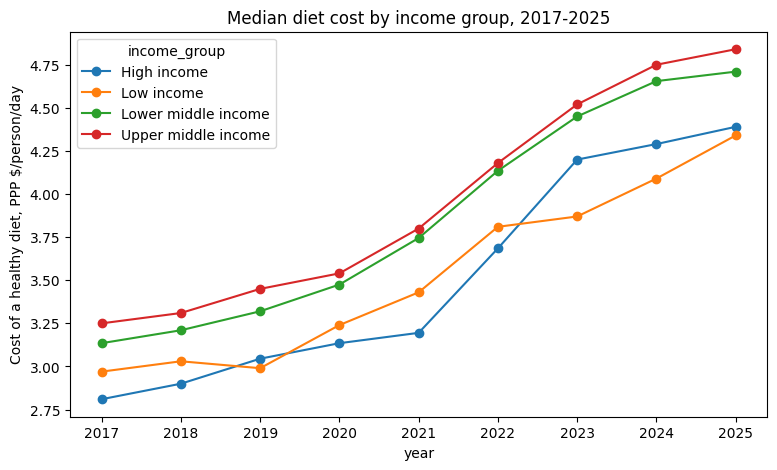

In [ ]:
import matplotlib.pyplot as plt
cost = (fpn[fpn["indicator"] == "CoHD_PPP"]
        .merge(countries[["iso3", "income_group"]], on="iso3"))

trend = (cost.groupby(["year", "income_group"])["value"]
             .median().unstack())
trend.plot(marker="o", figsize=(9,5))
plt.ylabel("Cost of a healthy diet, PPP $/person/day")
plt.title("Median diet cost by income group, 2017-2025")

**Food group composition, 2021**

Text(0.5, 0, 'Share of total diet cost')

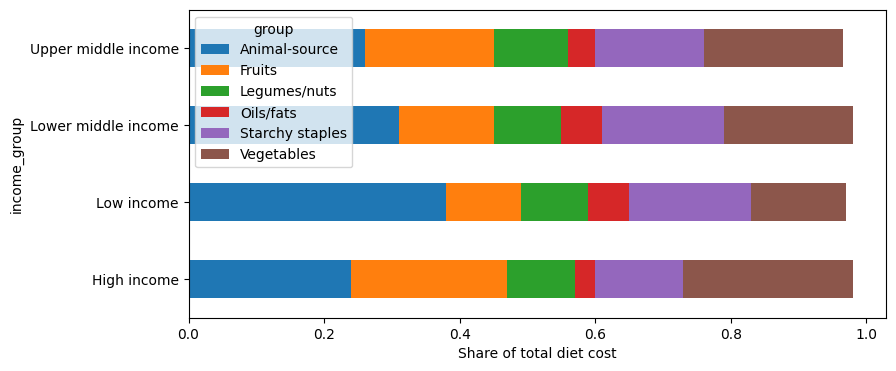

In [ ]:
groups = {"ss":"Starchy staples","v":"Vegetables","f":"Fruits",
          "asf":"Animal-source","lns":"Legumes/nuts","of":"Oils/fats"}

comp = (fpn[fpn["indicator"].isin([f"CoHD_{g}_prop" for g in groups])]
        .merge(countries[["iso3","income_group"]], on="iso3"))
comp["group"] = comp["indicator"].str.extract(r"CoHD_(\w+)_prop")[0].map(groups)

(comp.groupby(["income_group","group"])["value"].median()
     .unstack().plot(kind="barh", stacked=True, figsize=(9,4)))
plt.xlabel("Share of total diet cost")

**survey vintage**: if the distribution has a long right tail, a handful of countries are being carried on very old income data, and their affordability estimates are correspondingly weak.

Text(0.5, 1.0, 'Survey vintage')

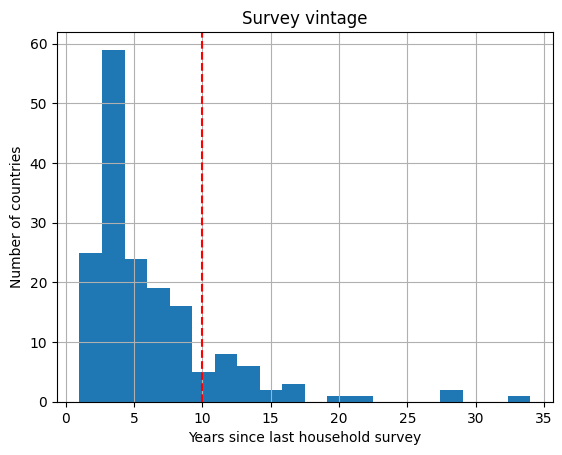

In [ ]:
latest["years_stale"].hist(bins=20)
plt.axvline(10, color="r", ls="--")
plt.xlabel("Years since last household survey")
plt.ylabel("Number of countries")
plt.title("Survey vintage")

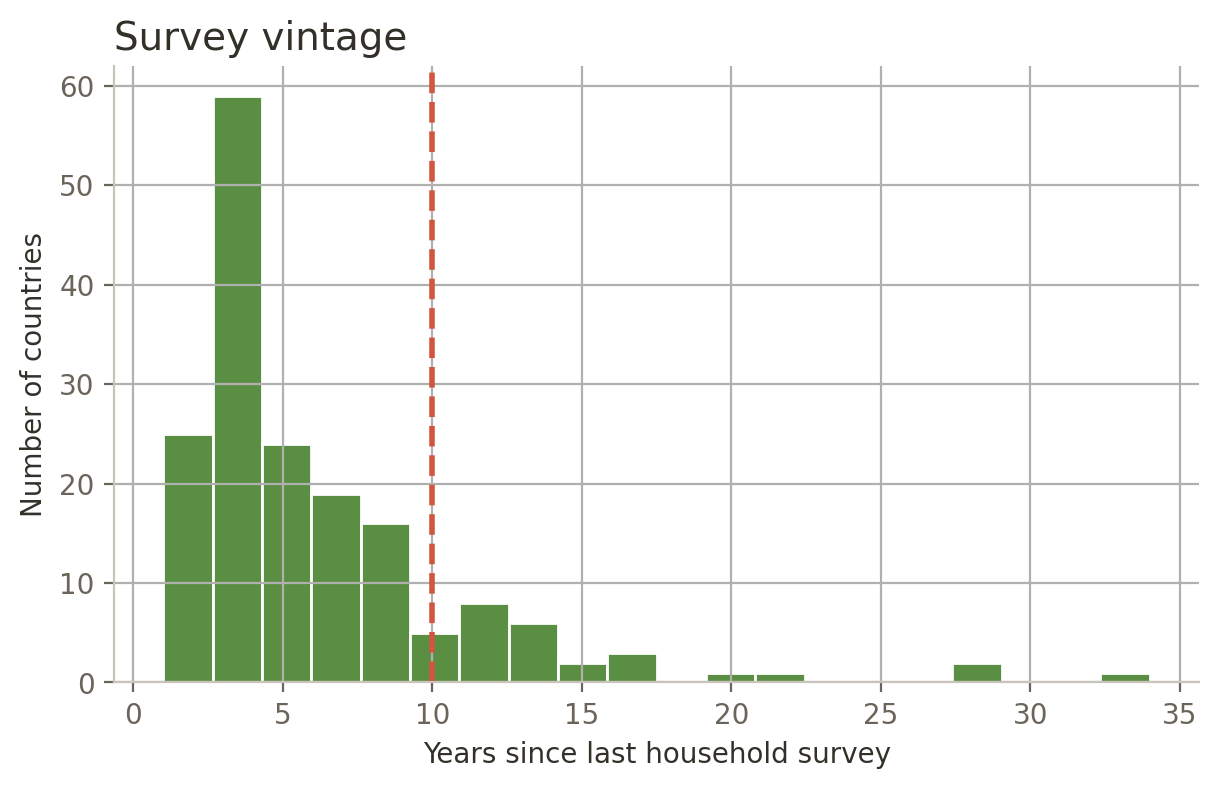

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4), dpi=200)

latest["years_stale"].hist(bins=20, ax=ax, color="#5A8F43", edgecolor="white", lw=0.8)
ax.axvline(10, color="#D1553F", ls="--", lw=2)

ax.set_xlabel("Years since last household survey", color="#33302A")
ax.set_ylabel("Number of countries", color="#33302A")
ax.set_title("Survey vintage", color="#33302A", fontsize=14, loc="left")

ax.tick_params(colors="#6B645A")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for s in ["left", "bottom"]:
    ax.spines[s].set_color("#C9C4BB")

fig.savefig("survey_vintage.png", transparent=True,
            bbox_inches="tight", pad_inches=0.15, dpi=200)

In [ ]:
from google.colab import files
files.download("survey_vintage.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
FEATURES = ["gdp_pc_ppp", "urban_share", "agri_land_share",
            "agri_value_added_share", "agri_employment_share",
            "food_production_index"]

usable = flags[flags["usable"]].index

X = (wdi[(wdi["indicator"].isin(FEATURES)) & (wdi["year"] == 2021)]
     .pivot(index="iso3", columns="indicator", values="value")
     .reindex(usable)[FEATURES])

X["gdp_pc_ppp"] = np.log(X["gdp_pc_ppp"])   # heavily right-skewed

print(f"complete cases: {X.dropna().shape[0]} of {len(usable)}\n")
print(X.corr().round(2).to_string())

complete cases: 135 of 138

indicator               gdp_pc_ppp  urban_share  agri_land_share  agri_value_added_share  agri_employment_share  food_production_index
indicator                                                                                                                             
gdp_pc_ppp                    1.00         0.73            -0.26                   -0.84                  -0.85                  -0.35
urban_share                   0.73         1.00            -0.19                   -0.64                  -0.77                  -0.28
agri_land_share              -0.26        -0.19             1.00                    0.21                   0.14                   0.12
agri_value_added_share       -0.84        -0.64             0.21                    1.00                   0.81                   0.30
agri_employment_share        -0.85        -0.77             0.14                    0.81                   1.00                   0.40
food_production_index      

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
Xc = X.dropna()
for i, c in enumerate(Xc.columns):
    print(f"{c:<26} VIF {variance_inflation_factor(Xc.values, i):.1f}")

gdp_pc_ppp                 VIF 5.2
urban_share                VIF 2.6
agri_land_share            VIF 1.1
agri_value_added_share     VIF 3.8
agri_employment_share      VIF 4.9
food_production_index      VIF 1.2


In [ ]:
Xc = X.dropna()
Xv = np.column_stack([np.ones(len(Xc)), Xc.values])
for i, c in enumerate(["const"] + list(Xc.columns)):
    print(f"{c:<26} VIF {variance_inflation_factor(Xv, i):.1f}")

const                      VIF 1.0
gdp_pc_ppp                 VIF 5.2
urban_share                VIF 2.6
agri_land_share            VIF 1.1
agri_value_added_share     VIF 3.8
agri_employment_share      VIF 4.9
food_production_index      VIF 1.2


In [ ]:
import statsmodels.api as sm
r = sm.OLS(Xc["agri_value_added_share"],
           sm.add_constant(Xc["gdp_pc_ppp"])).fit()
Xc["agri_excess"] = r.resid

In [ ]:
cohd = (fpn[(fpn["indicator"] == "CoHD_PPP") & (fpn["year"] == 2021)]
        .set_index("iso3")["value"])

rows = []
for iso3 in Xc.index:
    if iso3 not in cohd.index:
        continue
    r = get_json(f"{PIP_BASE}/pip", params={
        "country": iso3, "year": 2021, "povline": round(float(cohd[iso3]), 2),
        "ppp_version": 2021, "fill_gaps": "true", "format": "json"})
    if r:
        for rec in r:
            rows.append({"iso3": iso3,
                         "cohd_ppp": float(cohd[iso3]),
                         "cannot_afford": rec.get("headcount"),
                         "survey_year": rec.get("survey_year"),
                         "welfare_type": rec.get("welfare_type")})

target = pd.DataFrame(rows).drop_duplicates("iso3").set_index("iso3")
print(target.shape)
print(target["cannot_afford"].describe())
save(target.reset_index(), "target")

  attempt 1/3 failed: HTTPSConnectionPool(host='api.worldbank.org', port=443): Read timed out. (read timeout=60)
  attempt 2/3 failed: HTTPSConnectionPool(host='api.worldbank.org', port=443): Read timed out. (read timeout=60)
  attempt 3/3 failed: HTTPSConnectionPool(host='api.worldbank.org', port=443): Read timed out. (read timeout=60)
  attempt 1/3 failed: HTTPSConnectionPool(host='api.worldbank.org', port=443): Read timed out. (read timeout=60)
  attempt 2/3 failed: HTTPSConnectionPool(host='api.worldbank.org', port=443): Read timed out. (read timeout=60)
  attempt 3/3 failed: HTTPSConnectionPool(host='api.worldbank.org', port=443): Read timed out. (read timeout=60)
  attempt 1/3 failed: HTTPSConnectionPool(host='api.worldbank.org', port=443): Read timed out. (read timeout=60)
  attempt 2/3 failed: HTTPSConnectionPool(host='api.worldbank.org', port=443): Read timed out. (read timeout=60)
(128, 4)
count    128.000000
mean       0.175805
std        0.238546
min        0.000000
25%    

PosixPath('data_cache/target.csv')

In [ ]:
import time

cohd = (fpn[(fpn["indicator"] == "CoHD_PPP") & (fpn["year"] == 2021)]
        .set_index("iso3")["value"])

wanted = [c for c in Xc.index if c in cohd.index]
print(f"{len(wanted)} countries to query")

cache_path = CACHE / "target_partial.csv"
done = {}
if cache_path.exists():
    prev = pd.read_csv(cache_path)
    done = {r["iso3"]: r.to_dict() for _, r in prev.iterrows()}
    print(f"resuming, {len(done)} already fetched")

for i, iso3 in enumerate(wanted, 1):
    if iso3 in done:
        continue
    line = round(float(cohd[iso3]), 2)
    try:
        resp = requests.get(f"{PIP_BASE}/pip", timeout=25, params={
            "country": iso3, "year": 2021, "povline": line,
            "ppp_version": 2021, "fill_gaps": "false", "format": "json"})
        resp.raise_for_status()
        recs = resp.json()
        if recs:
            r = recs[0]
            done[iso3] = {"iso3": iso3, "cohd_ppp": line,
                          "cannot_afford": r.get("headcount"),
                          "survey_year": r.get("survey_year"),
                          "welfare_type": r.get("welfare_type")}
        else:
            done[iso3] = {"iso3": iso3, "cohd_ppp": line, "cannot_afford": None,
                          "survey_year": None, "welfare_type": None}
    except Exception as e:
        print(f"  {iso3}: {type(e).__name__}")
        time.sleep(1)
        continue

    if i % 10 == 0:
        pd.DataFrame(done.values()).to_csv(cache_path, index=False)
        got = sum(v["cannot_afford"] is not None for v in done.values())
        print(f"  {i}/{len(wanted)}, {got} with values")
    time.sleep(0.2)

target = pd.DataFrame(done.values()).set_index("iso3")
pd.DataFrame(done.values()).to_csv(cache_path, index=False)
print(target["cannot_afford"].describe())
save(target.reset_index(), "target")

130 countries to query
  10/130, 5 with values
  20/130, 11 with values
  30/130, 18 with values
  40/130, 27 with values
  50/130, 31 with values
  60/130, 36 with values
  70/130, 43 with values
  80/130, 48 with values
  90/130, 51 with values
  100/130, 58 with values
  110/130, 64 with values
  120/130, 69 with values
  130/130, 74 with values
count    74.000000
mean      0.105785
std       0.195128
min       0.000000
25%       0.001925
50%       0.008600
75%       0.079900
max       0.786300
Name: cannot_afford, dtype: float64
saved target: 130 rows x 5 cols -> data_cache/target.csv


PosixPath('data_cache/target.csv')

In [ ]:
pub = (fpn[(fpn["indicator"] == "CoHD_headcount") & (fpn["year"] == 2021)]
       .set_index("iso3")["value"])

cmp = target.join(pub.rename("published")).dropna()
cmp["published"] = cmp["published"] / 100 if cmp["published"].max() > 1 else cmp["published"]

print(cmp[["cannot_afford", "published"]].describe().round(3))
print(f"\ncorrelation: {cmp['cannot_afford'].corr(cmp['published']):.3f}")
print(cmp[["cohd_ppp", "cannot_afford", "published"]].head(15).round(3).to_string())

       cannot_afford  published
count         74.000     74.000
mean           0.106      0.264
std            0.195      0.251
min            0.000      0.009
25%            0.002      0.042
50%            0.009      0.178
75%            0.080      0.418
max            0.786      0.876

correlation: 0.853
      cohd_ppp  cannot_afford  published
iso3                                    
ARM       3.80          0.058      0.568
AUT       2.42          0.005      0.034
BEL       2.26          0.000      0.009
BEN       3.07          0.288      0.622
BFA       2.97          0.412      0.627
BGR       3.93          0.019      0.350
BIH       4.54          0.013      0.148
BOL       3.96          0.050      0.089
BRA       3.97          0.106      0.312
CAF       3.63          0.786      0.871
CAN       3.52          0.002      0.018
CHE       2.63          0.000      0.012
CHN       3.13          0.000      0.166
CIV       2.91          0.190      0.505
CMR       3.41          0.324      0

In [ ]:
FOOD_SHARE = 0.52
line = round(float(cohd[iso3]) / FOOD_SHARE, 2)